#  Artificial Intelligence and Machine Learning. Implementation of Convolutional Neural Network using Keras.

In [2]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
train_dir = "/content/drive/MyDrive/AI/week5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI/week5/FruitinAmazon/test"

# Task 1: Data Understanding and Visualization

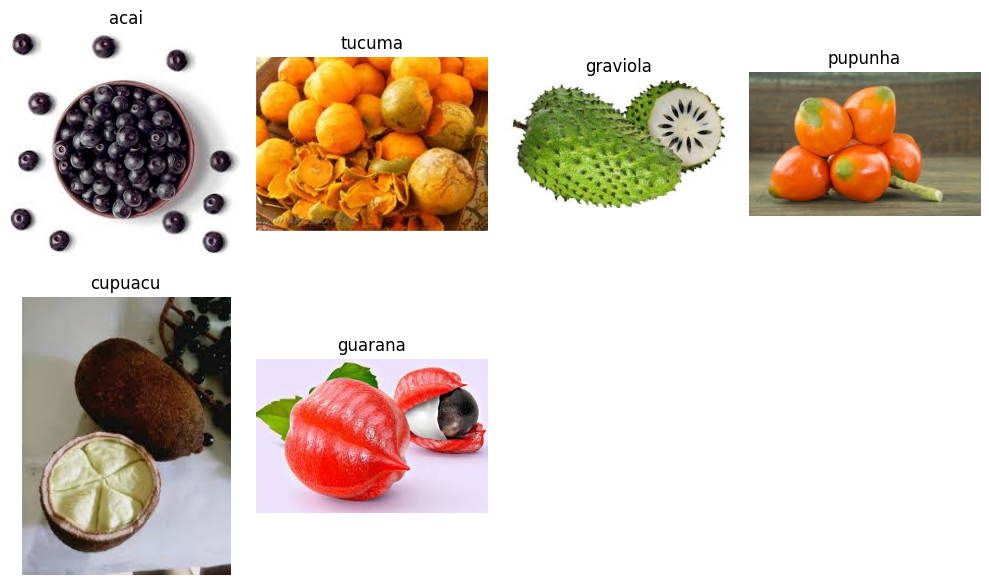

In [5]:
class_names = os.listdir(train_dir)

images = []
labels = []

# Pick one random image from each class
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)
        images.append(img)
        labels.append(class_name)

# Plot images (2 rows grid)
plt.figure(figsize=(10, 6))

for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Check for corrupted images
corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()  # check corruption
            except (IOError, SyntaxError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


# Task 2: Loading and Preprocessing Image Data

In [7]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset='training',
  seed=123
)
num_classes = len(train_ds.class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [8]:
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3: Implementing CNN

In [9]:
model = keras.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Task 4: Compilin and Training the Model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.1250 - loss: 1.7945
Epoch 1: val_loss improved from None to 1.22779, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.1250 - loss: 1.7826 - val_accuracy: 0.6667 - val_loss: 1.2278
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.3108 - loss: 1.5879
Epoch 2: val_loss improved from 1.22779 to 0.87175, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 561ms/step - accuracy: 0.2917 - loss: 1.5994 - val_accuracy: 0.7222 - val_loss: 0.8718
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5411 - loss: 1.3257
Epoch 3: val_loss did not improve from 0.87175
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 414ms/step - accuracy: 0.5139 - loss: 1.2917 - val_accuracy: 0.6111 - val_loss: 1.3882
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.5486 - loss: 1.2074
Epoch 4: val_loss did not improve from 0.87175
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 765ms/step - accuracy: 0.5833 - loss: 1.1520 - val_accuracy: 0.6111 - val_loss: 0.9989
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.7772 - loss: 0.8026
Epoch 5: val_loss improved from 0.87175 to 0.66282, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7222 - loss: 0.8436 - val_accuracy: 0.7222 - val_loss: 0.6628
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.7743 - loss: 0.6831
Epoch 6: val_loss did not improve from 0.66282
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 0.7917 - loss: 0.7022 - val_accuracy: 0.7778 - val_loss: 0.8036
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8247 - loss: 0.5621
Epoch 7: val_loss did not improve from 0.66282
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.8333 - loss: 0.5613 - val_accuracy: 0.7778 - val_loss: 0.9698
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8490 - loss: 0.5221
Epoch 8: val_loss improved from 0.66282 to 0.59331, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 482ms/step - accuracy: 0.8750 - loss: 0.4669 - val_accuracy: 0.8333 - val_loss: 0.5933
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9606 - loss: 0.2402
Epoch 9: val_loss improved from 0.59331 to 0.33271, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.9444 - loss: 0.2648 - val_accuracy: 0.8889 - val_loss: 0.3327
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9699 - loss: 0.1651
Epoch 10: val_loss did not improve from 0.33271
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step - accuracy: 0.9722 - loss: 0.1679 - val_accuracy: 0.8333 - val_loss: 0.5041
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9902 - loss: 0.0974
Epoch 11: val_loss did not improve from 0.33271
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 717ms/step - accuracy: 0.9861 - loss: 0.0917 - val_accuracy: 0.7778 - val_loss: 0.6930
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9902 - loss: 0.0512
Epoch 12: val_loss did not improve from 0.33271
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 516ms/step - accuracy: 0.9861 - loss: 0.0546 - val_accuracy: 0.8333 - val_loss: 0.3921
Epoch 13/250
3/3 ━━━━━━━━


Epoch 18: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 794ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.8333 - val_loss: 0.3189
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 19: val_loss did not improve from 0.31891
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8889 - val_loss: 0.3195
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 20: val_loss did not improve from 0.31891
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8889 - val_loss: 0.3332
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 1.0000 - loss: 0.0011
Epoch 21: val_loss did not improve from 0.31891
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8889 - val_loss: 0.3223
Epoch 22/250
3/3 ━━━━━━━


Epoch 22: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 544ms/step - accuracy: 1.0000 - loss: 9.0618e-04 - val_accuracy: 0.8889 - val_loss: 0.3071
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 1.0000 - loss: 6.9697e-04
Epoch 23: val_loss improved from 0.30705 to 0.29755, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 23: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 867ms/step - accuracy: 1.0000 - loss: 7.1239e-04 - val_accuracy: 0.8889 - val_loss: 0.2976
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 1.0000 - loss: 6.4093e-04
Epoch 24: val_loss did not improve from 0.29755
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 528ms/step - accuracy: 1.0000 - loss: 6.2416e-04 - val_accuracy: 0.8889 - val_loss: 0.3018
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 1.0000 - loss: 5.9391e-04
Epoch 25: val_loss did not improve from 0.29755
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 423ms/step - accuracy: 1.0000 - loss: 5.8945e-04 - val_accuracy: 0.8333 - val_loss: 0.3087
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 1.0000 - loss: 4.8504e-04
Epoch 26: val_loss did not improve from 0.29755
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 1.0000 - loss: 5.2839e-04 - val_accuracy: 0.8333 - val_loss: 0.3

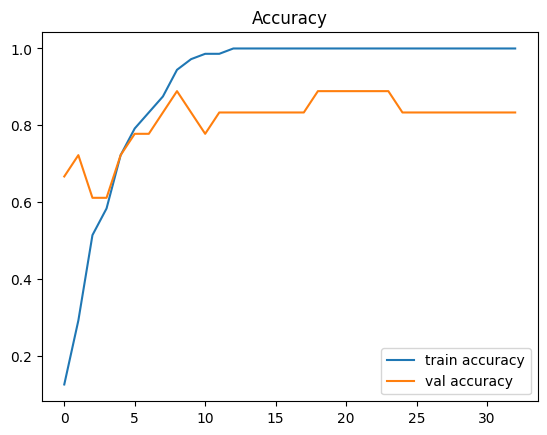

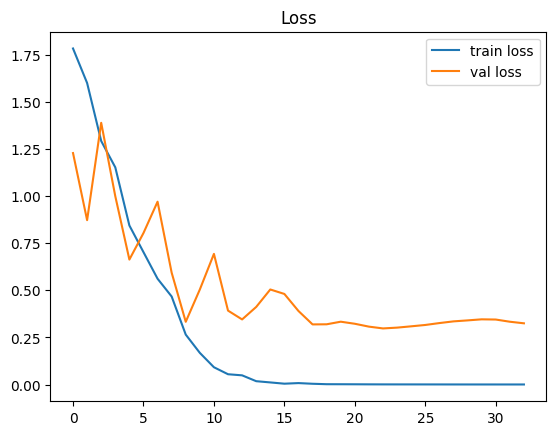

In [13]:
# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

# Task 5: Evaluating the Model

In [14]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [15]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.7000 - loss: 1.4693
Test Loss: 1.4693
Test Accuracy: 0.7000


# Task 6: Saving and Loading the Model

In [16]:
model.save("/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/cnn_fruit_model.h5")

In [17]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/cnn_fruit_model.h5")

In [18]:
loss, acc = loaded_model.evaluate(test_ds)

print(f"Loaded Model Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step - accuracy: 0.7000 - loss: 1.4693
Loaded Model Accuracy: 0.7000


# Task 7: Predictions and Classification Report

In [19]:
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


In [20]:
from sklearn.metrics import classification_report

labels = np.unique(y_true)

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=[class_names[i] for i in labels]
))

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
      tucuma       0.38      0.60      0.46         5
    graviola       0.71      1.00      0.83         5
     pupunha       1.00      0.60      0.75         5
     cupuacu       0.80      0.80      0.80         5
     guarana       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.78      0.70      0.70        30
weighted avg       0.78      0.70      0.70        30

